In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import supervised_loss


In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 3070


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=16,
    in_chans=3,
    embed_dim=256,
    depth=4,
    num_heads=4,
    num_bins=32,
    dropout=0.1,
).to(device)

In [5]:
dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    scale_xy=2.8,
    return_paths=True,
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)


=== SHAPES ===
img_a: torch.Size([3, 128, 128])
img_b: torch.Size([3, 128, 128])
vision_a: torch.Size([32, 3])
vision_b: torch.Size([32, 3])
pose: torch.Size([4])

=== PATHS ===
dataset/scene_000/images/pair_000_cam1.png
dataset/scene_000/images/pair_000_cam2.png
pose: tensor([0.2845, 0.0000, 0.0000, 1.0000])

=== CAMERAS ===
camera2 raw:
{'position': [-0.9713846941258638, -0.23751163343718976, 0.0], 'R': [[0.9173887862838087, -0.39799222957329256, 0.0], [0.0, 0.0, 1.0], [0.39799222957329256, 0.9173887862838087, 0.0]], 't': [0.7966096410175333, 0.0, 0.6044940693157518], 'K': [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]]}


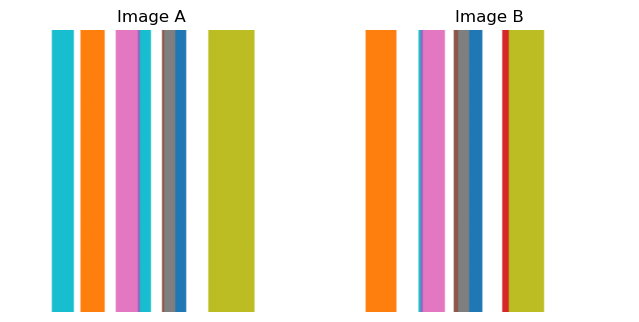

=== TRANSLATION (raw) ===
tensor([0.7966, 0.0000, 0.6045])

=== YOUR POSE ===
tensor([0.2845, 0.0000, 0.0000, 1.0000])

=== COMPARE XY ===
T_rel xy: tensor([0.7966, 0.0000])
pose xy: tensor([0.2845, 0.0000])

=== POSE (first sample) ===
tx: 0.285, ty: 0.000
yaw (rad): 0.000
yaw (deg): 0.00


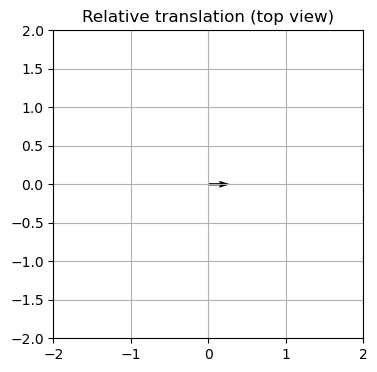

In [12]:
import torch
import matplotlib.pyplot as plt

def camera_to_T(cam):
    R = torch.tensor(cam["R"], dtype=torch.float32)
    t = torch.tensor(cam["t"], dtype=torch.float32)
    T = torch.eye(4)
    T[:3,:3] = R
    T[:3,3] = t
    return T

def bugg_check():

    dataset = SceneTwoPairsDataset("dataset", return_paths=True)

    idx = 0
    sample = dataset[idx]

    img_a, vision_a, img_b, vision_b, pose, path_a, path_b, camera1, camera2 = sample

    print("=== SHAPES ===")
    print("img_a:", img_a.shape)
    print("img_b:", img_b.shape)
    print("vision_a:", vision_a.shape)
    print("vision_b:", vision_b.shape)
    print("pose:", pose.shape)

    print("\n=== PATHS ===")
    print(path_a)
    print(path_b)
    print("pose:", pose)

    # Visa första sample i batch
    
    imgA = img_a.permute(1,2,0).cpu().numpy()
    imgB = img_b.permute(1,2,0).cpu().numpy()


    print("\n=== CAMERAS ===")

    print("camera2 raw:")
    print(camera2)

    fig, axs = plt.subplots(1, 2, figsize=(8,4))
    axs[0].imshow(imgA)
    axs[0].set_title("Image A")
    axs[1].imshow(imgB)
    axs[1].set_title("Image B")
    for ax in axs:
        ax.axis("off")
    plt.show()

    T1 = camera_to_T(camera1)
    T2 = camera_to_T(camera2)

    T_rel = T2 @ torch.linalg.inv(T1)

    print("=== TRANSLATION (raw) ===")
    print(T_rel[:3,3])

    print("\n=== YOUR POSE ===")
    print(pose)

    # jämför xy
    print("\n=== COMPARE XY ===")
    print("T_rel xy:", T_rel[:2,3])
    print("pose xy:", pose[:2])


    # === Pose tolkning ===
    tx, ty, s, c = pose
    yaw = torch.atan2(s, c)

    print("\n=== POSE (first sample) ===")
    print(f"tx: {tx:.3f}, ty: {ty:.3f}")
    print(f"yaw (rad): {yaw:.3f}")
    print(f"yaw (deg): {yaw * 180 / torch.pi:.2f}")

    # Rita pil för rörelse
    plt.figure(figsize=(4,4))
    plt.quiver(0, 0, tx.item(), ty.item(), angles='xy', scale_units='xy', scale=1)
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.grid()
    plt.title("Relative translation (top view)")
    plt.show()


bugg_check()

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

model.train()
for epoch in range(10):
    total = 0.0

    for batch in loader:
        img_a, vision_a, img_b, vision_b, pose_ab = batch

        img_a = img_a.to(device, non_blocking=True)
        img_b = img_b.to(device, non_blocking=True)
        vision_a = vision_a.to(device, non_blocking=True)
        pose_ab = pose_ab.to(device, non_blocking=True)

        pred_vision, pred_pose = model(img_a, img_b)

        loss, loss_vis, loss_pose = supervised_loss(
            pred_vision, vision_a,
            pred_pose, pose_ab,
            lambda_pose=1.0,
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += loss.item()

    print(f"Epoch {epoch+1}: loss={total / len(loader):.4f}")

In [ ]:
# Inference + utskrift + plottar på samma dataset som träningen
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Samma dataset som i träningen, men utan shuffle för stabil visualisering
infer_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

def pose_to_text(pose_4):
    """
    pose_4: tensor [tx, ty, sin(yaw), cos(yaw)]
    """
    tx, ty, s, c = pose_4.tolist()
    yaw_deg = np.degrees(np.arctan2(s, c))
    return f"tx={tx:.3f}, ty={ty:.3f}, yaw={yaw_deg:.1f}°"

def show_image_pair(img_a, img_b, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_a.permute(1, 2, 0).cpu().clamp(0, 1))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b.permute(1, 2, 0).cpu().clamp(0, 1))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    if title is not None:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
vision_b = vision_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, pred_pose = model(img_a, img_b)

# Skriv ut resultat för några samples
n_show = min(4, img_a.shape[0])
for i in range(n_show):
    print(f"Sample {i}")
    print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
    print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

    pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
    print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
    print()

In [ ]:
# Plotta bildpar
for i in range(n_show):
    show_image_pair(
        img_a[i].detach().cpu(),
        img_b[i].detach().cpu(),
        title=f"Sample {i} | GT pose: {pose_to_text(pose_ab[i].detach().cpu())}"
    )

# Plotta vision-output för första samplet
sample_idx = 0
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    ax.plot(bins, gt, label="GT")
    ax.plot(bins, pr, label="Pred")
    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()